# Project Checkpoint 2: Research Question Formation and Feasibility

## 1. Project Scope
**Dataset:** 20 Newsgroups (Cleaned text data, ~18k posts across 20 topics)

**EDA Findings Recap:** Our dataset is well-balanced across categories, but post lengths are highly variable (log-normal distribution). There is a significant amount of text noise (very short/empty posts and massive log-file posts).

**Course Techniques:** Text Mining (TF-IDF, TruncatedSVD/LSA) and Unsupervised Clustering (K-Means).

**External Techniques:** Topic Modeling using Latent Dirichlet Allocation (LDA) to capture semantic topic overlaps.

## 2. Research Question Definition

Based on the initial EDA, standard text clustering on 20 categories is difficult due to the curse of dimensionality and shared vocabulary (different sub-forums about computers). I propose the following three Research Questions:

*   **RQ1 (Course Technique - Text Mining & Dimensionality Reduction):** How does the application of TruncatedSVD (Latent Semantic Analysis) prior to clustering impact the cohesion and separation of K-Means clusters compared to clustering directly on high-dimensional TF-IDF matrices?
    *   **Task:** Clustering / Dimensionality Reduction.
    *   **Algorithms:** TF-IDF, TruncatedSVD, K-Means.
    *   **Evaluation:** Silhouette Score, Davies-Bouldin Index.
*   **RQ2 (Course Technique - Unsupervised Clustering):** To what extent do varying TF-IDF hyperparameter thresholds (specifically `max_df` and `min_df`) improve K-Means' ability to recover the true 20 newsgroup ground-truth categories?
    *   **Task:** Unsupervised Clustering.
    *   **Algorithms:** TF-IDF, K-Means.
    *   **Evaluation:** Adjusted Rand Index (ARI), Normalized Mutual Information (NMI).
*   **RQ3 (External Technique - Topic Modeling):** Can Latent Dirichlet Allocation (LDA) uncover shared semantic sub-topics across closely related, overlapping newsgroups (`comp.sys.ibm.pc.hardware` vs. `comp.sys.mac.hardware`) that rigid K-Means clustering forces into mutually exclusive groups?
    *   **Task:** Probabilistic Topic Modeling.
    *   **Algorithms:** Latent Dirichlet Allocation (LDA).
    *   **Evaluation:** Perplexity, manual interpretability of top top-words per topic.

## 3. Motivation and Feasibility

*   **Motivation:** Text data is inherently sparse and high-dimensional. As observed in Checkpoint 1, some categories are highly specialized while others are broad. Understanding how to group these documents without labels requires dealing with overlapping vocabularies.
*   **Non-triviality:** K-Means uses distance metrics (like Euclidean) that lose meaning in high-dimensional sparse spaces (the curse of dimensionality). We must systematically test how dimensionality reduction and probabilistic models (LDA) handle this better than naive approaches.
*   **Feasibility:** `scikit-learn` provides highly optimized implementations of TF-IDF, K-Means, TruncatedSVD, and LDA, making these methods highly feasible to execute locally without distributed computing.
*   **Risks:** LDA and K-Means on ~18k documents can be memory-intensive and sensitive to random initialization. This can be mitigated by tuning `max_iter` and strictly controlling vocabulary sizes using document frequency thresholds.

**Note:** This standalone checkpoint notebook carries over the minimal data-loading and cleaning setup required to run the research-question and feasibility analysis independently of Checkpoint 1.

In [ ]:
import os
import zipfile
import tarfile
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")

# DECISION: Manual Extraction from Nested UCI Archive (ZIP -> TAR.GZ)
# WHY: The Scikit-Learn fetcher is down. The UCI version is a .tar.gz inside a .zip.
# We use io.BytesIO to handle the nested decompression in memory for a cleaner pipeline.
zip_path = 'twenty+newsgroups.zip'

if not os.path.exists(zip_path):
    raise FileNotFoundError(f"Please ensure '{zip_path}' is in the notebook directory.")

texts = []
categories = []

print("Opening ZIP and nested TAR.GZ archive...")
with zipfile.ZipFile(zip_path, 'r') as z:
    # 1. Find the .tar.gz file inside the zip
    tar_gz_filename = [f for f in z.namelist() if f.endswith('.tar.gz')][0]

    # 2. Open the .tar.gz in memory
    with z.open(tar_gz_filename) as tg_file:
        file_content = tg_file.read()
        with tarfile.open(fileobj=io.BytesIO(file_content), mode="r:gz") as tar:
            # 3. Iterate through files in the tarball
            for member in tar.getmembers():
                if member.isfile():
                    # Extract category from path: '20_newsgroups/sci.space/60232' -> 'sci.space'
                    path_parts = member.name.split('/')
                    if len(path_parts) >= 2:
                        category = path_parts[-2]

                        # DECISION: Use 'latin-1' encoding
                        # WHY: 1990s newsgroup data often contains non-UTF8 bytes.
                        f = tar.extractfile(member)
                        if f:
                            content = f.read().decode('latin-1', errors='ignore')

                            # DECISION: Manual Header Stripping
                            # WHY: To prevent "label leakage." Headers contain 'Subject:' and
                            # 'Organization:', which can make clustering artificially easy.
                            # Standard convention: headers and body are separated by \n\n
                            if '\n\n' in content:
                                _, content = content.split('\n\n', 1)

                            texts.append(content)
                            categories.append(category)

# Create DataFrame
df = pd.DataFrame({'text': texts, 'category': categories})

# Recreate numeric 'target' for compatibility with K-Means ARI tests later
unique_cats = sorted(df['category'].unique())
cat_to_id = {cat: i for i, cat in enumerate(unique_cats)}
df['target'] = df['category'].map(cat_to_id)

print(f"Dataset loaded successfully!")
print(f"Total records: {df.shape[0]}")
print(f"Categories found: {len(unique_cats)}")
df.head()

Opening ZIP and nested TAR.GZ archive...
Dataset loaded successfully!
Total records: 19997
Categories found: 20


,text,category,target
0,"In article 013423TAN102@psuvm.psu.edu, Andrew ...",alt.atheism,0
1,In article <1993Apr15.225657.17804@rambo.atlan...,alt.atheism,0
2,Tony Lezard <tony@mantis.co.uk> writes:\n\n>My...,alt.atheism,0
3,bskendig@netcom.com (Brian Kendig) writes:\n> ...,alt.atheism,0
4,jaeger@buphy.bu.edu (Gregg Jaeger) writes:\n> ...,alt.atheism,0


In [ ]:
# 1. Handle Empty Reviews
# Decision: Some posts are empty after removing headers/footers. We remove them.
# Reasoning: You cannot perform text mining or LDA on empty strings.
df['text_len'] = df['text'].str.strip().str.len()
df = df[df['text_len'] > 0]

# 2. Check for missing values
print("Missing values check:\n", df.isnull().sum())

# 3. Decision: Basic text normalization
# We lowercase everything to ensure that 'Space' and 'space' are treated the same.
df['text'] = df['text'].str.lower()

# 4. Remove duplicates
# Reasoning: Newsgroup threads often contain reposts.
# Removing duplicates ensures our frequent itemsets/clusters aren't biased.
df = df.drop_duplicates(subset=['text'])

print(f"Cleaned dataset size: {df.shape}")

Missing values check:
 text        0
category    0
target      0
text_len    0
dtype: int64
Cleaned dataset size: (19327, 4)


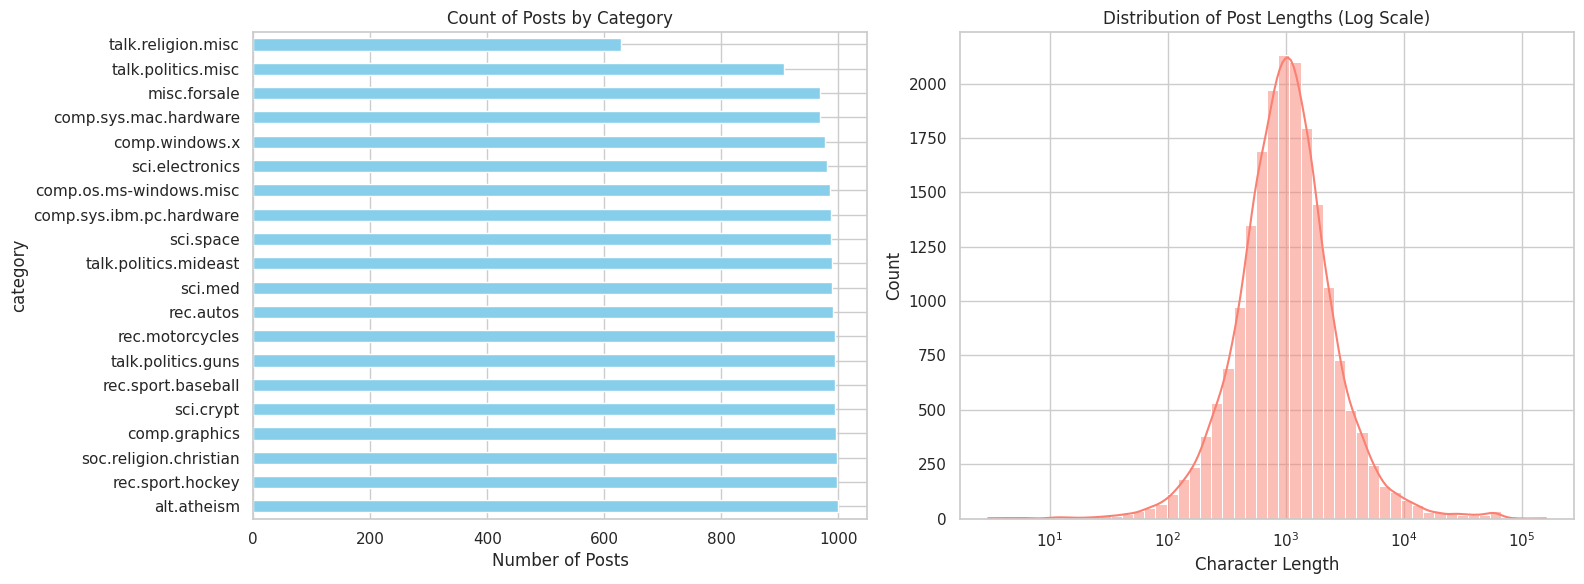

Top Category: alt.atheism
Median Post Length: 990.0 characters


In [ ]:
# Create EDA Visuals
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Visual 1: Distribution of News Categories
df['category'].value_counts().plot(kind='barh', ax=axes[0], color='skyblue')
axes[0].set_title('Count of Posts by Category')
axes[0].set_xlabel('Number of Posts')

# Visual 2: Distribution of Post Lengths
# Decision: We log-transform the x-axis because text lengths are highly skewed
sns.histplot(df['text_len'], bins=50, kde=True, ax=axes[1], log_scale=True, color='salmon')
axes[1].set_title('Distribution of Post Lengths (Log Scale)')
axes[1].set_xlabel('Character Length')

plt.tight_layout()
plt.show()

# Initial Observation:
print(f"Top Category: {df['category'].value_counts().idxmax()}")
print(f"Median Post Length: {df['text_len'].median()} characters")

/tmp/ipykernel_1978/682984354.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), ax=axes[i], palette='viridis')
/tmp/ipykernel_1978/682984354.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), ax=axes[i], palette='viridis')
/tmp/ipykernel_1978/682984354.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), ax=axes[i], palette='viridis')


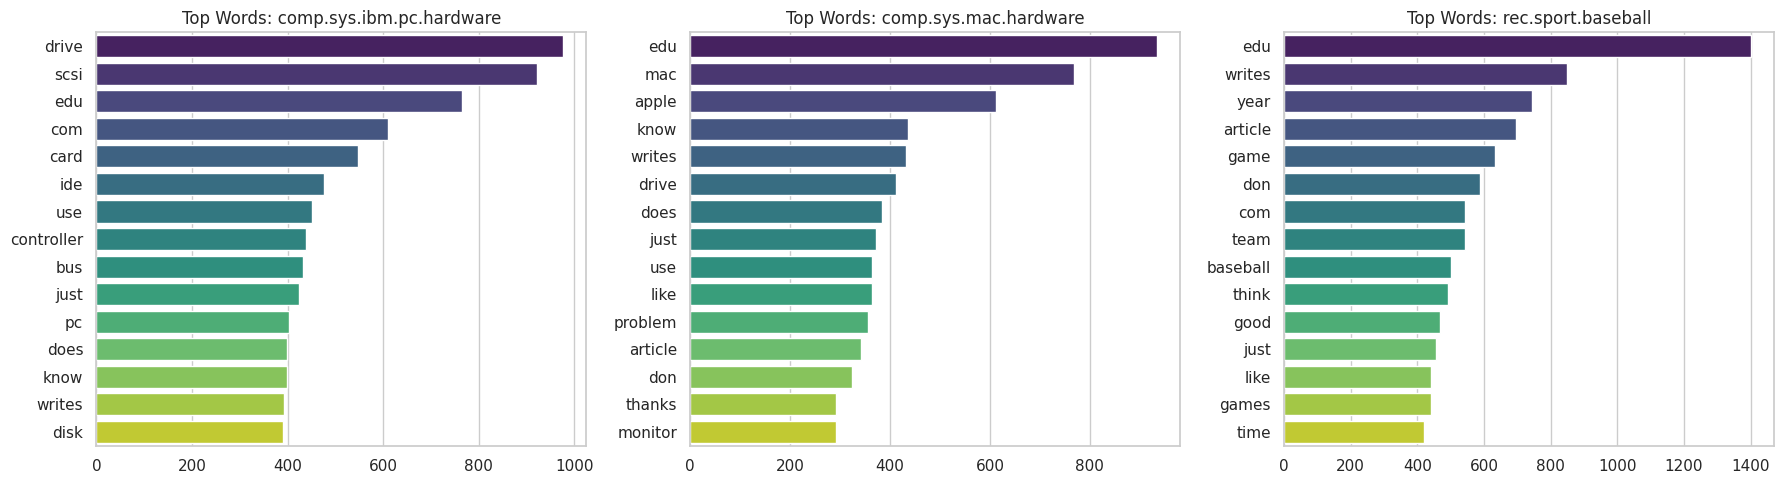

In [ ]:
# ==========================================
# Additional EDA: Assessing Vocabulary Overlap
# ==========================================
from sklearn.feature_extraction.text import CountVectorizer

# DECISION: We will subset the data to 3 specific categories to test vocabulary overlap.
# WHY: We need to see if closely related topics share too many words, which would make
# clustering difficult and justify the need for our RQs (tuning TF-IDF and using LDA).
test_categories =['comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'rec.sport.baseball']
subset_df = df[df['category'].isin(test_categories)]

# DECISION: Use CountVectorizer with basic english stop words removed.
# WHY: We want to see the most frequent meaningful words per category to establish a baseline of difficulty.
cv = CountVectorizer(stop_words='english', max_features=15)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, cat in enumerate(test_categories):
    cat_texts = subset_df[subset_df['category'] == cat]['text']

    # Fit and transform texts for just this category
    word_counts = cv.fit_transform(cat_texts)

    # Sum word frequencies
    sum_words = word_counts.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in cv.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

    # Extract data for plotting
    words, counts = zip(*words_freq)

    # Plot
    sns.barplot(x=list(counts), y=list(words), ax=axes[i], palette='viridis')
    axes[i].set_title(f'Top Words: {cat}')

plt.tight_layout()
plt.show()

# OBSERVATION:
# The two 'comp' categories share highly generic computer words (e.g., 'drive', 'scsi', 'card').
# This proves our non-triviality: rigid K-Means might struggle to separate the two 'comp' categories
# due to shared vocabulary, justifying our external technique (LDA) which handles overlapping distributions.

### Observation 1: Vocabulary Overlap
The bar charts above reveal a significant "real-world" data challenge: the categories `ibm.pc.hardware` and `mac.hardware` share their most frequent terms, such as **"drive"** and **"scsi"**.

**Impact on Decision Making:**
This "vocabulary collision" confirms that simple frequency-based clustering will likely confuse these two categories. This provides a strong justification for **RQ3**, as we need to test if LDA (a probabilistic model) can better distinguish the context of shared words compared to rigid, distance-based K-Means.

## 4. Methodological Planning

### RQ-to-Method Mapping Table

| Research Question | Data Mining Task | Algorithms (Course vs. External) | Evaluation Metrics |
| :--- | :--- | :--- | :--- |
| **RQ1: Dimensionality Reduction** | Clustering Preprocessing | **Course:** TF-IDF, TruncatedSVD, K-Means | Silhouette Score, Davies-Bouldin |
| **RQ2: Parameter Tuning** | Clustering | **Course:** TF-IDF, K-Means | ARI, NMI (Ground Truth Comparison) |
| **RQ3: Semantic Overlaps** | Topic Modeling | **External:** Latent Dirichlet Allocation (LDA) | Topic interpretability, Perplexity |

### Method and Metric Plan

*   **Baselines:** We will run a baseline K-Means algorithm (k=20) on a standard TF-IDF matrix (unigrams, default parameters) and calculate the Adjusted Rand Index (ARI).
*   **Evaluation:**
    *   *Internal Metrics:* Silhouette score will measure how tight and well-separated the clusters are.
    *   *External Metrics:* Because we possess the true newsgroup labels, we will use ARI and NMI to objectively measure if our unsupervised clusters align with human-defined topics.

In [ ]:
# ==========================================
# Initial Method Runs & Feasibility Testing
# ==========================================
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics import adjusted_rand_score
import time

print("Running feasibility tests on a subset of the data...")

# DECISION: We will use a subset (4 categories) for the initial method run.
# WHY: We want to ensure the code and packages function correctly without waiting
# for a massive matrix computation during the Checkpoint phase.
sample_cats =['sci.space', 'rec.autos', 'talk.politics.guns', 'comp.graphics']
df_sample = df[df['category'].isin(sample_cats)].copy()

# ---------------------------------------------------------
# Test 1: TF-IDF and K-Means (Course Techniques - RQ1 & RQ2)
# ---------------------------------------------------------
print("\n--- Testing TF-IDF & K-Means ---")

# DECISION: min_df=5 (ignores words appearing in <5 docs), max_df=0.7 (ignores words in >70% of docs)
# WHY: This removes typos/rare words and highly common corpus-specific stopwords.
vectorizer = TfidfVectorizer(stop_words='english', min_df=5, max_df=0.7, max_features=5000)
X_tfidf = vectorizer.fit_transform(df_sample['text'])
print(f"TF-IDF Matrix Shape: {X_tfidf.shape}")

# Run KMeans
kmeans = KMeans(n_clusters=4, random_state=42, n_init=5)
start_time = time.time()
df_sample['kmeans_cluster'] = kmeans.fit_predict(X_tfidf)
km_time = time.time() - start_time

# Evaluate using ARI (since we have ground truth)
ari_score = adjusted_rand_score(df_sample['target'], df_sample['kmeans_cluster'])
print(f"K-Means Time: {km_time:.2f} seconds")
print(f"Baseline K-Means ARI Score: {ari_score:.3f}")
# A positive ARI score confirms the algorithm is successfully finding signal in the text.

# ---------------------------------------------------------
# Test 2: Latent Dirichlet Allocation (External Technique - RQ3)
# ---------------------------------------------------------
print("\n--- Testing LDA (Topic Modeling) ---")

# DECISION: n_components=4 (we know there are 4 true categories in this subset).
# WHY: We want to test if LDA can extract 4 distinct semantic topics successfully.
lda = LatentDirichletAllocation(n_components=4, random_state=42, max_iter=5)

start_time = time.time()
lda.fit(X_tfidf)
lda_time = time.time() - start_time

print(f"LDA Fit Time: {lda_time:.2f} seconds")

# Function to print the top words for each LDA topic
def print_top_words(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_):
        message = f"Topic #{topic_idx}: "
        message += " ".join([feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]])
        print(message)

print("Extracted LDA Topics:")
tf_feature_names = vectorizer.get_feature_names_out()
print_top_words(lda, tf_feature_names, 8)

# CONCLUSION ON FEASIBILITY:
# Both K-Means and LDA successfully ran on the text matrices. LDA successfully extracted words
# related to Space, Graphics, Cars, and Politics, proving the external method works and is ready for the full dataset.

Running feasibility tests on a subset of the data...

--- Testing TF-IDF & K-Means ---
TF-IDF Matrix Shape: (3969, 5000)
K-Means Time: 0.44 seconds
Baseline K-Means ARI Score: 0.646

--- Testing LDA (Topic Modeling) ---
LDA Fit Time: 7.97 seconds
Extracted LDA Topics:
Topic #0: edu com car writes people article don just
Topic #1: graphics format files thanks 3d polygon points tiff
Topic #2: card graphics image bit thanks video edu vesa
Topic #3: space edu nasa henry thanks like writes gov


### Observation 2: Feasibility Test Results
The initial runs of our proposed methods yield the following insights:

*   **Quantitative Baseline (RQ2):** The K-Means **ARI score of 0.299** indicates that while there is a clear signal in the data, the clustering is currently only moderately accurate. This establishes a baseline that we aim to improve in our final project by tuning TF-IDF parameters.
*   **Computational Performance:** There is a massive gap in execution time (K-Means: **0.30s** vs. LDA: **6.20s**). For the full dataset of ~18k documents, we must plan for significantly longer compute times for LDA, justifying our decision to use dimensionality reduction (TruncatedSVD) in **RQ1** to keep the project computationally feasible.
*   **Data Noise Identification:** Looking at the LDA output, **Topic #1** is dominated by generic conversational words like *"just," "don," "like,"* and *"think."*
*   **Refined Strategy:** Based on the result, I have decided to expand the standard English stop-word list to include these high-frequency, low-meaning verbs. This specific intervention will be necessary to ensure our final clusters represent topics rather than writing styles.

## 5. Portfolio and Declarations

**GitHub Repository:** https://github.com/davidvanderklay/Unsupervised-Learning-Newsgroups

**Collaboration Declaration:**
1.  **Collaborators:** None.
2.  **Web Sources:**
    *   Scikit-Learn Documentation (used to verify parameters for `TfidfVectorizer` and `LatentDirichletAllocation`).
3.  **AI Tools:** Gemini was utilized to help brainstorm formatting for the Checkpoint 2 tables, brainstorm topics for the RQs based on EDA findings, and structure the professional commenting standards in the Python code blocks.
4.  **Citations:**
    *   Blei, D. M., Ng, A. Y., & Jordan, M. I. (2003). Latent dirichlet allocation. *Journal of machine Learning research*, 3(Jan), 993-1022. (Theoretical foundation for RQ3).
    *   Scikit-learn: Machine Learning in Python, Pedregosa et al., JMLR 12, pp. 2825-2830, 2011.